In [1]:
from one.api import ONE
from brainbox.population.decode import get_spike_counts_in_bins
from brainbox.io.one import SpikeSortingLoader, SessionLoader
from brainbox.ephys_plots import plot_brain_regions
from brainbox.behavior.wheel import velocity
from brainbox.task.trials import get_event_aligned_raster, get_psth
from iblatlas.atlas import AllenAtlas
from brainwidemap import bwm_query, load_good_units, load_trials_and_mask, bwm_units
from brainbox.behavior.training import compute_performance, plot_psychometric, plot_reaction_time
from brainbox.task.trials import find_trial_ids
from brainbox.io.one import SessionLoader
from brainbox.population.decode import get_spike_counts_in_bins
from pathlib import Path
from brainbox.task.trials import get_event_aligned_raster, get_psth
from brainbox import singlecell

c:\Users\debot\miniconda3\envs\info-decom\lib\site-packages\ibllib\atlas\__init__.py:205: DeprecationWarning: ibllib.atlas is deprecated. Please install iblatlas using "pip install iblatlas" and use this module instead
  warnings.warn('ibllib.atlas is deprecated. Please install iblatlas using "pip install iblatlas" and use '


In [2]:
## Standard python imports and IDTxL

import numpy as np
from idtxl.active_information_storage import ActiveInformationStorage
from idtxl.data import Data
from idtxl.bivariate_pid import BivariatePID
from idtxl.multivariate_pid import MultivariatePID
from tqdm.notebook import tqdm
from matplotlib import pyplot as plt
import seaborn as sns
import itertools

In [3]:
## setup one and bwm

one = ONE(base_url="https://openalyx.internationalbrainlab.org", password="international")
bwm_df = bwm_query()

# use frozen bwm data


def download_data(one, bwm_df, idx):
    pid = bwm_df.pid[idx]
    spikes, clusters = load_good_units(one, pid, compute_metrics=False)
    return spikes, clusters


# PID decomposition and group by region
# just for expidency, find neurons that are nice


def find_important_neurons(data):
    mean_spike_rate = np.mean(data, axis=(1, 0))
    important_neurons = np.mean(data, axis=1) > mean_spike_rate
    return np.argwhere(important_neurons == True).reshape(
        -1,
    )


# now run PID with each neuron as source and others as target
def generate_sources(neurons):
    global_sources = []
    for idx in range(len(neurons)):
        mask = np.ones(neurons.shape, bool)
        mask[idx] = False
        sources = []
        for combinations in itertools.combinations(neurons[mask], 2):
            sources.append(combinations)
        global_sources.append(sources)
    return np.asarray(global_sources)


def computePID(sources, targets, data):
    PID_storage = np.zeros((len(targets), len(sources[0]), 4))
    for index, target in tqdm(enumerate(targets)):
        pid_info = []
        target = int(target)
        for r in tqdm(range(len(sources[index])), leave=False):
            S = sources[index][r]
            partial_decomposition = MultivariatePID()
            settings_SxPID = {"pid_estimator": "SxPID", "lags_pid": [2, 2]}
            result = partial_decomposition.analyse_single_target(
                data=data, settings=settings_SxPID, target=target, sources=S
            )
            pid_info.append(
                [
                    result.get_single_target(target)["avg"][(1,),][2],
                    result.get_single_target(target)["avg"][(2,),][2],
                    result.get_single_target(target)["avg"][
                        (1,),
                        (2,),
                    ][2],
                    result.get_single_target(target)["avg"][
                        (
                            1,
                            2,
                        ),
                    ][2],
                ]
            )
        pid_info = np.asarray(pid_info)
        PID_storage[index, :, :] = pid_info
    return PID_storage


def computePID_bivariate(sources, targets, data):

    PID_storage = np.zeros((len(targets), len(sources[0]), 4))
    for index, target in tqdm(enumerate(targets)):
        pid_info = []
        target = int(target)
        for r in tqdm(range(len(sources[index])), leave=False):
            S = sources[index][r]
            partial_decomposition = MultivariatePID()
            settings_tartu = {"pid_estimator": "TartuPID", "lags_pid": [2, 2]}
            result = partial_decomposition.analyse_single_target(
                data=data, settings=settings_tartu, target=target, sources=S
            )
            pid_info.append(
                [
                    result.get_single_target(target)["unq_s1"],
                    result.get_single_target(target)["unq_s2"],
                    result.get_single_target(target)["shd_s1_s2"],
                    result.get_single_target(target)["syn_s1_s2"],
                ]
            )
        pid_info = np.asarray(pid_info)
        PID_storage[index, :, :] = pid_info
    return PID_storage


def generate_groupings(neuron_location, neurons):
    targets = np.arange(len(neurons), dtype=np.int32)
    sources = generate_sources(targets)

    # now for each target, we will have the source grouping
    # source_grouping = np.empty_like(sources)
    in_out_grouping_logic = np.zeros((sources.shape[0], sources.shape[1]))
    for t in range(sources.shape[0]):
        # for each target region
        target_neuron = neuron_location[t]
        for s in range(sources.shape[1]):
            n1 = sources[t][s][0]
            n2 = sources[t][s][1]
            source_neuron_1 = neuron_location[n1]
            source_neuron_2 = neuron_location[n2]
            # source_grouping[t,s,0] = neuron_location[n1]
            # source_grouping[t,s,1] = neuron_location[n2]
            # 1 is same region, 2 is one from same region and another from another, 3 is all from another region
            # we can make this more fine tuned, however combinatorial explosion imminent
            # how to deal with this?
            # targeted hypothesis makes more sense
            if source_neuron_1 == target_neuron and source_neuron_2 == target_neuron:
                # this means everything is in one region
                in_out_grouping_logic[t, s] = 1
            elif (source_neuron_1 == target_neuron and source_neuron_2 != target_neuron) or (
                source_neuron_1 != target_neuron and source_neuron_2 == target_neuron
            ):
                in_out_grouping_logic[t, s] = 2
            else:
                in_out_grouping_logic[t, s] = 3
    return in_out_grouping_logic


def build_decoding_array(target_variable_array, source_variable_array):
    decoding_array = []
    for neuron1 in range(source_variable_array.shape[0]):
        spikes1 = source_variable_array[neuron1, :]
        for neuron2 in range(neuron1, source_variable_array.shape[0]):
            if neuron1 == neuron2:
                continue
            spikes2 = source_variable_array[neuron2, :]
            data = np.vstack([target_variable_array, spikes1, spikes2])
            decoding_array.append(data)
    decoding_array = np.asarray(decoding_array)
    return decoding_array


def generate_groupings_decoding(neuron_location, neurons):
    groupings = []
    regions = []

    for n1 in range(len(neurons)):
        n1_region = neuron_location[n1]

        for n2 in range(n1, len(neurons)):

            if n1 == n2:

                continue

            n2_region = neuron_location[n2]
            if n1_region == n2_region:
                groupings.append(1)
            else:
                groupings.append(0)
            regions.append([n1_region, n2_region])
    return np.asarray(groupings), np.asarray(regions)


def compute_pid_neurons(data):

    neuron_combinations = data.shape[0]
    PID_storage = np.zeros((neuron_combinations, 4))
    for idx in tqdm(range(neuron_combinations)):
        z = data[idx, :, 0]
        x1 = data[idx, :, 1]
        x2 = data[idx, :, 2]
        subset_data = Data(np.vstack([x1, x2, z]), "ps", normalise=False)
        settings_SxPID = {"pid_estimator": "SxPID", "lags_pid": [0, 0]}

        target = int(2)
        sources = [0, 1]
        partial_decomposition = MultivariatePID()
        result = partial_decomposition.analyse_single_target(
            data=subset_data, settings=settings_SxPID, target=target, sources=sources
        )
        pid_info = [
            result.get_single_target(target)["avg"][(1,),][2],
            result.get_single_target(target)["avg"][(2,),][2],
            result.get_single_target(target)["avg"][
                (1,),
                (2,),
            ][2],
            result.get_single_target(target)["avg"][
                (
                    1,
                    2,
                ),
            ][2],
        ]
        pid_info = np.asarray(pid_info)
        PID_storage[idx, :] = pid_info
    return PID_storage


def compute_pid_neurons_bivariate(data):

    neuron_combinations = data.shape[0]
    PID_storage = np.zeros((neuron_combinations, 4))
    for idx in tqdm(range(neuron_combinations)):
        z = data[idx, :, 0]
        x1 = data[idx, :, 1]
        x2 = data[idx, :, 2]
        subset_data = Data(np.vstack([x1, x2, z]), "ps", normalise=False)
        settings_tartu = {"pid_estimator": "TartuPID", "lags_pid": [0, 0]}

        target = int(2)
        sources = [0, 1]
        partial_decomposition = BivariatePID()
        result = partial_decomposition.analyse_single_target(
            data=subset_data, settings=settings_tartu, target=target, sources=sources
        )
        pid_info = [
            result.get_single_target(target)["unq_s1"],
            result.get_single_target(target)["unq_s2"],
            result.get_single_target(target)["shd_s1_s2"],
            result.get_single_target(target)["syn_s1_s2"],
        ]
        pid_info = np.asarray(pid_info)
        PID_storage[idx, :] = pid_info
    return PID_storage


# how to group these regions


def group_decoding_results(PID_decoding, Rdecoding, regions):

    unique_regions = np.unique(regions)
    inregion_pid = np.zeros((len(unique_regions), 4))
    inregion_count = np.zeros((len(unique_regions)))
    outregion_pid = np.zeros((len(unique_regions), 4))
    outregion_count = np.zeros((len(unique_regions)))

    inregion_std_calculator = [[] * i for i in range(len(unique_regions))]
    outregion_std_calculator = [[] * i for i in range(len(unique_regions))]

    for region_id, region in enumerate(unique_regions):

        # in group
        for idx in range(Rdecoding.shape[0]):  # iterate over all possibilites
            r1 = Rdecoding[idx, 0]
            r2 = Rdecoding[idx, 1]

            if r1 == region and r2 == region:
                inregion_pid[region_id] = inregion_pid[region_id] + PID_decoding[idx, :]
                inregion_count[region_id] += 1
                inregion_std_calculator[region_id].append(PID_decoding[idx, :])
            else:
                outregion_pid[region_id] = outregion_pid[region_id] + PID_decoding[idx, :]
                outregion_count[region_id] += 1
                outregion_std_calculator[region_id].append(PID_decoding[idx, :])

    # just compute the std
    inregion_std = np.zeros((len(unique_regions), 4))
    outregion_std = np.zeros((len(unique_regions), 4))
    for idx, x in enumerate(inregion_std_calculator):
        inregion_std[idx, :] = np.nanstd(x, axis=0)

    for idx, x in enumerate(outregion_std_calculator):
        outregion_std[idx, :] = np.nanstd(x, axis=0)

    return (
        inregion_pid,
        inregion_count,
        outregion_pid,
        outregion_count,
        inregion_std,
        outregion_std,
    )


def combine_multidimensional_pid(pid_storage_condition, groupings, neuron_location):

    unique_regions = np.unique(neuron_location)
    inregion_pid = np.zeros((len(unique_regions), 4))
    inregion_count = np.zeros((len(unique_regions)))
    outregion_pid = np.zeros((len(unique_regions), 4))
    outregion_count = np.zeros((len(unique_regions)))
    mixedregion_pid = np.zeros((len(unique_regions), 4))
    mixedregion_count = np.zeros((len(unique_regions)))

    # similar stuff
    # 1 is same region, 2 is one from same region and another from another, 3 is all from another region
    inregion_std_calculator = [[] * i for i in range(len(unique_regions))]
    outregion_std_calculator = [[] * i for i in range(len(unique_regions))]
    mixedregion_std_calculator = [[] * i for i in range(len(unique_regions))]

    for idx, region_name in enumerate(neuron_location):
        location = np.argwhere(region_name == unique_regions)

        inregions = np.argwhere(groupings[idx] == 1).reshape(
            -1,
        )
        mixedregions = np.argwhere(groupings[idx] == 2).reshape(
            -1,
        )
        outregions = np.argwhere(groupings[idx] == 3).reshape(
            -1,
        )

        # compute means for region
        inregion_pid_single_neuron = pid_storage_condition[idx, inregions, :]
        inregion_mean = np.nanmean(inregion_pid_single_neuron, axis=0)

        mixedregion_pid_single_neuron = pid_storage_condition[idx, mixedregions, :]
        mixedregion_mean = np.nanmean(mixedregion_pid_single_neuron, axis=0)

        outregion_pid_single_neuron = pid_storage_condition[idx, outregions, :]
        outregion_mean = np.nanmean(outregion_pid_single_neuron, axis=0)

        # 3 means for each neuron, now assign to global
        inregion_pid[location, :] = inregion_pid[location, :] + inregion_mean
        inregion_count[location] += 1
        inregion_std_calculator[
            location.reshape(
                -1,
            )[0]
        ].append(inregion_mean)

        mixedregion_pid[location, :] = mixedregion_pid[location, :] + mixedregion_mean
        mixedregion_count[location] += 1
        mixedregion_std_calculator[
            location.reshape(
                -1,
            )[0]
        ].append(mixedregion_mean)

        outregion_pid[location, :] = outregion_pid[location, :] + outregion_mean
        outregion_count[location] += 1
        outregion_std_calculator[
            location.reshape(
                -1,
            )[0]
        ].append(outregion_mean)

    # do something similar
    inregion_std = np.zeros((len(unique_regions), 4))
    outregion_std = np.zeros((len(unique_regions), 4))
    mixedregion_std = np.zeros((len(unique_regions), 4))

    for idx, x in enumerate(inregion_std_calculator):
        inregion_std[idx, :] = np.nanstd(x, axis=0)

    for idx, x in enumerate(outregion_std_calculator):
        outregion_std[idx, :] = np.nanstd(x, axis=0)

    for idx, x in enumerate(mixedregion_std_calculator):
        mixedregion_std[idx, :] = np.nanstd(x, axis=0)

    return (
        inregion_pid,
        inregion_count,
        inregion_std,
        outregion_pid,
        outregion_count,
        outregion_std,
        mixedregion_pid,
        mixedregion_count,
        mixedregion_std,
    )

Loading bwm_query results from fixtures/2023_12_bwm_release.csv


In [4]:
spikes_insertion_one, clusters_insertion_one = download_data(one, bwm_df, 9)
eid = bwm_df.eid[9]
trials, mask = load_trials_and_mask(one, eid, min_rt=0.08, max_rt=2.0, nan_exclude="default")

In [5]:
correct_trials = trials[mask][trials[mask]["feedbackType"] == 1]
visible_trials_left = correct_trials.contrastLeft.isin([1, 0.25, 0.125, 0.0625])
visible_trials_right = correct_trials.contrastRight.isin([1, 0.25, 0.125, 0.0625])
visible_trials = visible_trials_left | visible_trials_right


time_window_stim = [0.0, 0.1]
events_stim = correct_trials.stimOn_times
events_stim_tw = np.array([events_stim + time_window_stim[0], events_stim + time_window_stim[1]]).T

## for left and right sided visible stimulus, only correct trials

spike_count_stim, cluster_id = get_spike_counts_in_bins(
    spikes_insertion_one["times"], spikes_insertion_one["clusters"], events_stim_tw
)

# also, now for single cells, to be used for a lag based analysis
p_eths, bin_counts_stim = singlecell.calculate_peths(
    spikes_insertion_one["times"],
    spikes_insertion_one["clusters"],
    cluster_id,
    align_times=events_stim,
    smoothing=False,
    bin_size=0.01,
    pre_time=0.0,
    post_time=0.1,
)

In [10]:
clusters_insertion_one.acronym.unique()

array(['MEA', 'opt', 'int', 'em', 'VPL', 'RT'], dtype=object)

In [19]:
# just get VPL and RT

important_neurons_stim = np.argwhere(clusters_insertion_one.acronym.isin(["VPL", "RT"])).reshape(
    -1,
)

In [18]:
left_stim_spike_data = np.asarray(bin_counts_stim[visible_trials_left, :, :], dtype=np.int32)
right_stim_spike_data = np.asarray(bin_counts_stim[visible_trials_right, :, :], dtype=np.int32)

spike_count_stim_data = spike_count_stim[:, visible_trials]
stim_side = visible_trials_left * 1 + visible_trials_right * -1

# remove zeros
stim_side = stim_side[stim_side != 0].values

In [21]:
# data for single cell analysis
data_left_stim = Data(
    left_stim_spike_data[:, important_neurons_stim, :], dim_order="rps", normalise=False
)
data_right_stim = Data(
    right_stim_spike_data[:, important_neurons_stim, :], dim_order="rps", normalise=False
)
sources_stim = generate_sources(np.arange(len(important_neurons_stim)))
targets_stim = np.arange(len(important_neurons_stim), dtype=np.int32)

neuron_location_stim = clusters_insertion_one["acronym"][important_neurons_stim].values
# regions = np.unique(neuron_location_stim)


groupings_singlecell_stim = generate_groupings(neuron_location_stim, important_neurons_stim)

Adding data with properties: 37 processes, 10 samples, 130 replications
overwriting existing data
Adding data with properties: 37 processes, 10 samples, 210 replications
overwriting existing data


In [23]:
pid_storage_left_stim = computePID(sources_stim, targets_stim, data=data_left_stim)
pid_storage_right_stim = computePID(sources_stim, targets_stim, data=data_right_stim)


spike_count_stim_data_important = spike_count_stim_data[important_neurons_stim, :]
decoding_array_stim = build_decoding_array(stim_side, spike_count_stim_data_important)

# transpose so that it is neurons x trials x spike_counts
# multivariate cause why not
# target is variable 0
decoding_array_stim = np.transpose(decoding_array_stim, (0, 2, 1))

PID_stim_decoding = compute_pid_neurons(decoding_array_stim)

_, Rdecoding_stim = generate_groupings_decoding(neuron_location_stim, important_neurons_stim)

(
    inregion_pid_stim_decoding,
    inregion_count_stim_decoding,
    outregion_pid_stim_decoding,
    outregion_count_stim_decoding,
    inregion_std_stim_decoding,
    outregion_std_stim_decoding,
) = group_decoding_results(PID_stim_decoding, Rdecoding_stim, neuron_location_stim)


(
    inregion_pid_stim_left,
    inregion_count_stim_left,
    inregion_std_stim_left,
    outregion_pid_stim_left,
    outregion_count_stim_left,
    outregion_std_stim_left,
    mixedregion_pid_stim_left,
    mixedregion_count_stim_left,
    mixedregion_std_stim_left,
) = combine_multidimensional_pid(
    pid_storage_left_stim, groupings_singlecell_stim, neuron_location_stim
)


(
    inregion_pid_stim_right,
    inregion_count_stim_right,
    inregion_std_stim_right,
    outregion_pid_stim_right,
    outregion_count_stim_right,
    outregion_std_stim_right,
    mixedregion_pid_stim_right,
    mixedregion_count_stim_right,
    mixedregion_std_stim_right,
) = combine_multidimensional_pid(
    pid_storage_right_stim, groupings_singlecell_stim, neuron_location_stim
)

0it [00:00, ?it/s]

  0%|          | 0/630 [00:00<?, ?it/s]

  0%|          | 0/630 [00:00<?, ?it/s]

  0%|          | 0/630 [00:00<?, ?it/s]

  0%|          | 0/630 [00:00<?, ?it/s]

...

  0%|          | 0/630 [00:00<?, ?it/s]

  0%|          | 0/630 [00:00<?, ?it/s]

  0%|          | 0/630 [00:00<?, ?it/s]

  0%|          | 0/666 [00:00<?, ?it/s]

Adding data with properties: 3 processes, 340 samples, 1 replications
overwriting existing data
Adding data with properties: 3 processes, 340 samples, 1 replications
overwriting existing data
Adding data with properties: 3 processes, 340 samples, 1 replications
overwriting existing data
Adding data with properties: 3 processes, 340 samples, 1 replications
overwriting existing data
Adding data with properties: 3 processes, 340 samples, 1 replications
overwriting existing data
Adding data with properties: 3 processes, 340 samples, 1 replications
overwriting existing data
Adding data with properties: 3 processes, 340 samples, 1 replications
overwriting existing data
Adding data with properties: 3 processes, 340 samples, 1 replications
overwriting existing data
Adding data with properties: 3 processes, 340 samples, 1 replications
overwriting existing data
Adding data with properties: 3 processes, 340 samples, 1 replications
overwriting existing data
Adding data with properties: 3 processes

In [29]:
## same for stimulus
mean_stim_right_inregion = inregion_pid_stim_right / inregion_count_stim_right.reshape(-1, 1)
mean_stim_right_outregion = outregion_pid_stim_right / outregion_count_stim_right.reshape(-1, 1)
mean_stim_right_mixedregion = mixedregion_pid_stim_right / mixedregion_count_stim_right.reshape(
    -1, 1
)


mean_stim_left_inregion = inregion_pid_stim_left / inregion_count_stim_left.reshape(-1, 1)
mean_stim_left_outregion = outregion_pid_stim_left / outregion_count_stim_left.reshape(-1, 1)
mean_stim_left_mixedregion = mixedregion_pid_stim_left / mixedregion_count_stim_left.reshape(-1, 1)

mean_stim_decoding_inregion = inregion_pid_stim_decoding / inregion_count_stim_decoding.reshape(
    -1, 1
)
mean_stim_decoding_outregion = outregion_pid_stim_decoding / outregion_count_stim_decoding.reshape(
    -1, 1
)

Text(0, 0.5, 'Redundancy')

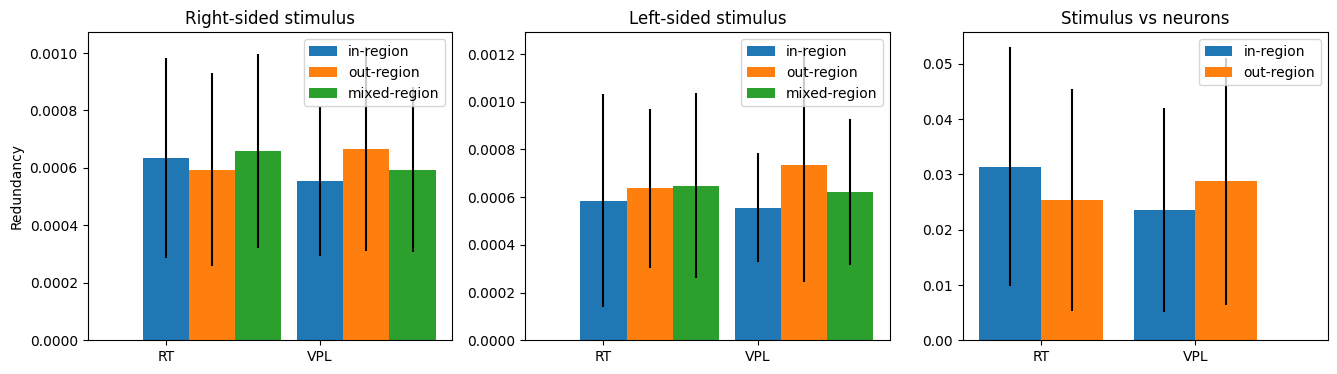

In [30]:
fig, ax = plt.subplots(figsize=(16, 4), ncols=3, sharex=True)
regions = mean_stim_right_inregion.shape[0]

ax[0].bar(
    np.arange(regions),
    mean_stim_right_inregion[:, 3],
    width=0.3,
    yerr=inregion_std_stim_right[:, 3],
    label="in-region",
)
ax[0].bar(
    np.arange(regions) + 0.3,
    mean_stim_right_outregion[:, 3],
    width=0.3,
    yerr=outregion_std_stim_right[:, 3],
    label="out-region",
)
ax[0].bar(
    np.arange(regions) + 0.6,
    mean_stim_right_mixedregion[:, 3],
    width=0.3,
    yerr=mixedregion_std_stim_right[:, 3],
    label="mixed-region",
)

ax[1].bar(
    np.arange(regions),
    mean_stim_left_inregion[:, 3],
    width=0.3,
    yerr=inregion_std_stim_left[:, 3],
    label="in-region",
)
ax[1].bar(
    np.arange(regions) + 0.3,
    mean_stim_left_outregion[:, 3],
    width=0.3,
    yerr=outregion_std_stim_left[:, 3],
    label="out-region",
)
ax[1].bar(
    np.arange(regions) + 0.6,
    mean_stim_left_mixedregion[:, 3],
    width=0.3,
    yerr=mixedregion_std_stim_left[:, 3],
    label="mixed-region",
)

ax[2].bar(
    np.arange(regions) - 0.2,
    mean_stim_decoding_inregion[:, 3],
    width=0.4,
    yerr=inregion_std_stim_decoding[:, 3],
    label="in-region",
)
ax[2].bar(
    np.arange(regions) + 0.2,
    mean_stim_decoding_outregion[:, 3],
    width=0.4,
    yerr=outregion_std_stim_decoding[:, 3],
    label="out-region",
)

ax[0].legend()
ax[1].legend()
ax[2].legend()

neuron_location_stim
ax[0].set_xticks(np.arange(regions), np.unique(neuron_location_stim))

ax[0].set_title("Right-sided stimulus")
ax[1].set_title("Left-sided stimulus")
ax[2].set_title("Stimulus vs neurons")
ax[0].set_ylabel("Redundancy")

Text(0, 0.5, 'Synergy')

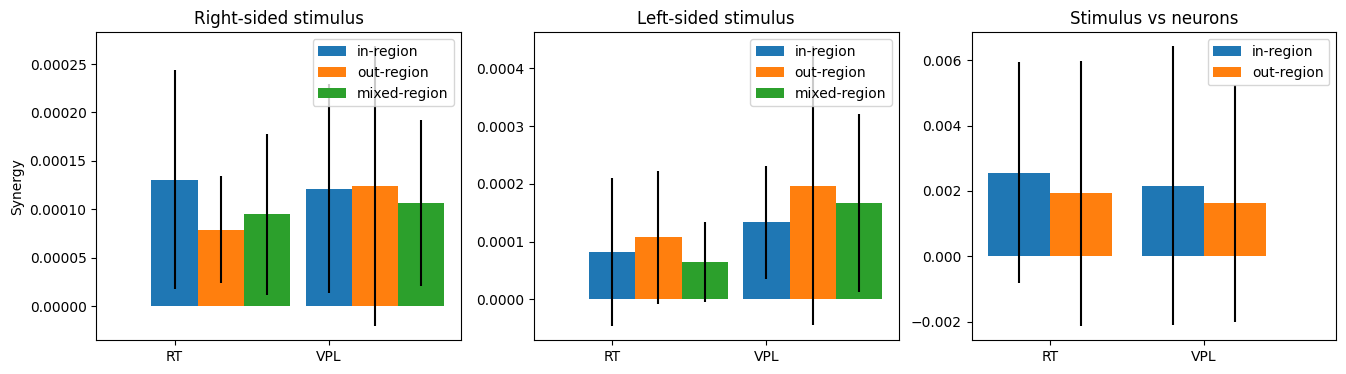

In [31]:
fig, ax = plt.subplots(figsize=(16, 4), ncols=3, sharex=True)
regions = mean_stim_right_inregion.shape[0]

ax[0].bar(
    np.arange(regions),
    mean_stim_right_inregion[:, 2],
    width=0.3,
    yerr=inregion_std_stim_right[:, 2],
    label="in-region",
)
ax[0].bar(
    np.arange(regions) + 0.3,
    mean_stim_right_outregion[:, 2],
    width=0.3,
    yerr=outregion_std_stim_right[:, 2],
    label="out-region",
)
ax[0].bar(
    np.arange(regions) + 0.6,
    mean_stim_right_mixedregion[:, 2],
    width=0.3,
    yerr=mixedregion_std_stim_right[:, 2],
    label="mixed-region",
)

ax[1].bar(
    np.arange(regions),
    mean_stim_left_inregion[:, 2],
    width=0.3,
    yerr=inregion_std_stim_left[:, 2],
    label="in-region",
)
ax[1].bar(
    np.arange(regions) + 0.3,
    mean_stim_left_outregion[:, 2],
    width=0.3,
    yerr=outregion_std_stim_left[:, 2],
    label="out-region",
)
ax[1].bar(
    np.arange(regions) + 0.6,
    mean_stim_left_mixedregion[:, 2],
    width=0.3,
    yerr=mixedregion_std_stim_left[:, 2],
    label="mixed-region",
)

ax[2].bar(
    np.arange(regions) - 0.2,
    mean_stim_decoding_inregion[:, 2],
    width=0.4,
    yerr=inregion_std_stim_decoding[:, 2],
    label="in-region",
)
ax[2].bar(
    np.arange(regions) + 0.2,
    mean_stim_decoding_outregion[:, 2],
    width=0.4,
    yerr=outregion_std_stim_decoding[:, 2],
    label="out-region",
)

ax[0].legend()
ax[1].legend()
ax[2].legend()

neuron_location_stim
ax[0].set_xticks(np.arange(regions), np.unique(neuron_location_stim))

ax[0].set_title("Right-sided stimulus")
ax[1].set_title("Left-sided stimulus")
ax[2].set_title("Stimulus vs neurons")
ax[0].set_ylabel("Synergy")

Text(0, 0.5, 'Unique Information - Source 1')

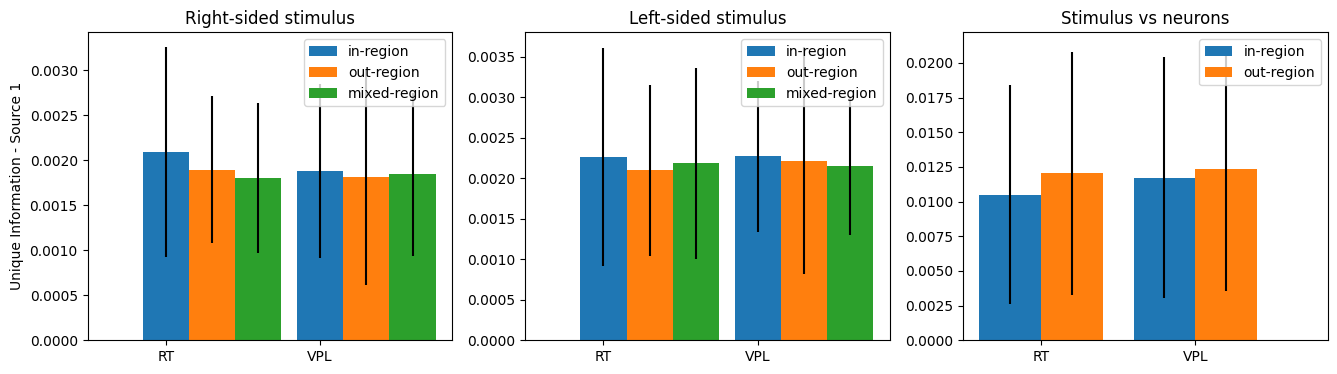

In [33]:
fig, ax = plt.subplots(figsize=(16, 4), ncols=3, sharex=True)
regions = mean_stim_right_inregion.shape[0]

ax[0].bar(
    np.arange(regions),
    mean_stim_right_inregion[:, 0],
    width=0.3,
    yerr=inregion_std_stim_right[:, 0],
    label="in-region",
)
ax[0].bar(
    np.arange(regions) + 0.3,
    mean_stim_right_outregion[:, 0],
    width=0.3,
    yerr=outregion_std_stim_right[:, 0],
    label="out-region",
)
ax[0].bar(
    np.arange(regions) + 0.6,
    mean_stim_right_mixedregion[:, 0],
    width=0.3,
    yerr=mixedregion_std_stim_right[:, 0],
    label="mixed-region",
)

ax[1].bar(
    np.arange(regions),
    mean_stim_left_inregion[:, 0],
    width=0.3,
    yerr=inregion_std_stim_left[:, 0],
    label="in-region",
)
ax[1].bar(
    np.arange(regions) + 0.3,
    mean_stim_left_outregion[:, 0],
    width=0.3,
    yerr=outregion_std_stim_left[:, 0],
    label="out-region",
)
ax[1].bar(
    np.arange(regions) + 0.6,
    mean_stim_left_mixedregion[:, 0],
    width=0.3,
    yerr=mixedregion_std_stim_left[:, 0],
    label="mixed-region",
)

ax[2].bar(
    np.arange(regions) - 0.2,
    mean_stim_decoding_inregion[:, 0],
    width=0.4,
    yerr=inregion_std_stim_decoding[:, 0],
    label="in-region",
)
ax[2].bar(
    np.arange(regions) + 0.2,
    mean_stim_decoding_outregion[:, 0],
    width=0.4,
    yerr=outregion_std_stim_decoding[:, 0],
    label="out-region",
)

ax[0].legend()
ax[1].legend()
ax[2].legend()

neuron_location_stim
ax[0].set_xticks(np.arange(regions), np.unique(neuron_location_stim))

ax[0].set_title("Right-sided stimulus")
ax[1].set_title("Left-sided stimulus")
ax[2].set_title("Stimulus vs neurons")
ax[0].set_ylabel("Unique Information - Source 1")

Text(0, 0.5, 'Unique Information - Source 2')

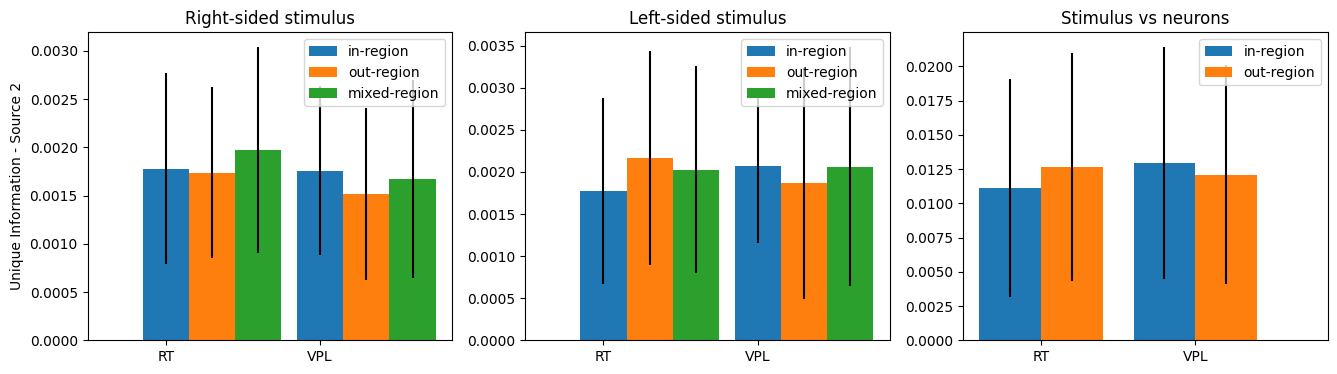

In [34]:
fig, ax = plt.subplots(figsize=(16, 4), ncols=3, sharex=True)
regions = mean_stim_right_inregion.shape[0]

ax[0].bar(
    np.arange(regions),
    mean_stim_right_inregion[:, 1],
    width=0.3,
    yerr=inregion_std_stim_right[:, 1],
    label="in-region",
)
ax[0].bar(
    np.arange(regions) + 0.3,
    mean_stim_right_outregion[:, 1],
    width=0.3,
    yerr=outregion_std_stim_right[:, 1],
    label="out-region",
)
ax[0].bar(
    np.arange(regions) + 0.6,
    mean_stim_right_mixedregion[:, 1],
    width=0.3,
    yerr=mixedregion_std_stim_right[:, 1],
    label="mixed-region",
)

ax[1].bar(
    np.arange(regions),
    mean_stim_left_inregion[:, 1],
    width=0.3,
    yerr=inregion_std_stim_left[:, 1],
    label="in-region",
)
ax[1].bar(
    np.arange(regions) + 0.3,
    mean_stim_left_outregion[:, 1],
    width=0.3,
    yerr=outregion_std_stim_left[:, 1],
    label="out-region",
)
ax[1].bar(
    np.arange(regions) + 0.6,
    mean_stim_left_mixedregion[:, 1],
    width=0.3,
    yerr=mixedregion_std_stim_left[:, 1],
    label="mixed-region",
)

ax[2].bar(
    np.arange(regions) - 0.2,
    mean_stim_decoding_inregion[:, 1],
    width=0.4,
    yerr=inregion_std_stim_decoding[:, 1],
    label="in-region",
)
ax[2].bar(
    np.arange(regions) + 0.2,
    mean_stim_decoding_outregion[:, 1],
    width=0.4,
    yerr=outregion_std_stim_decoding[:, 1],
    label="out-region",
)

ax[0].legend()
ax[1].legend()
ax[2].legend()

neuron_location_stim
ax[0].set_xticks(np.arange(regions), np.unique(neuron_location_stim))

ax[0].set_title("Right-sided stimulus")
ax[1].set_title("Left-sided stimulus")
ax[2].set_title("Stimulus vs neurons")
ax[0].set_ylabel("Unique Information - Source 2")

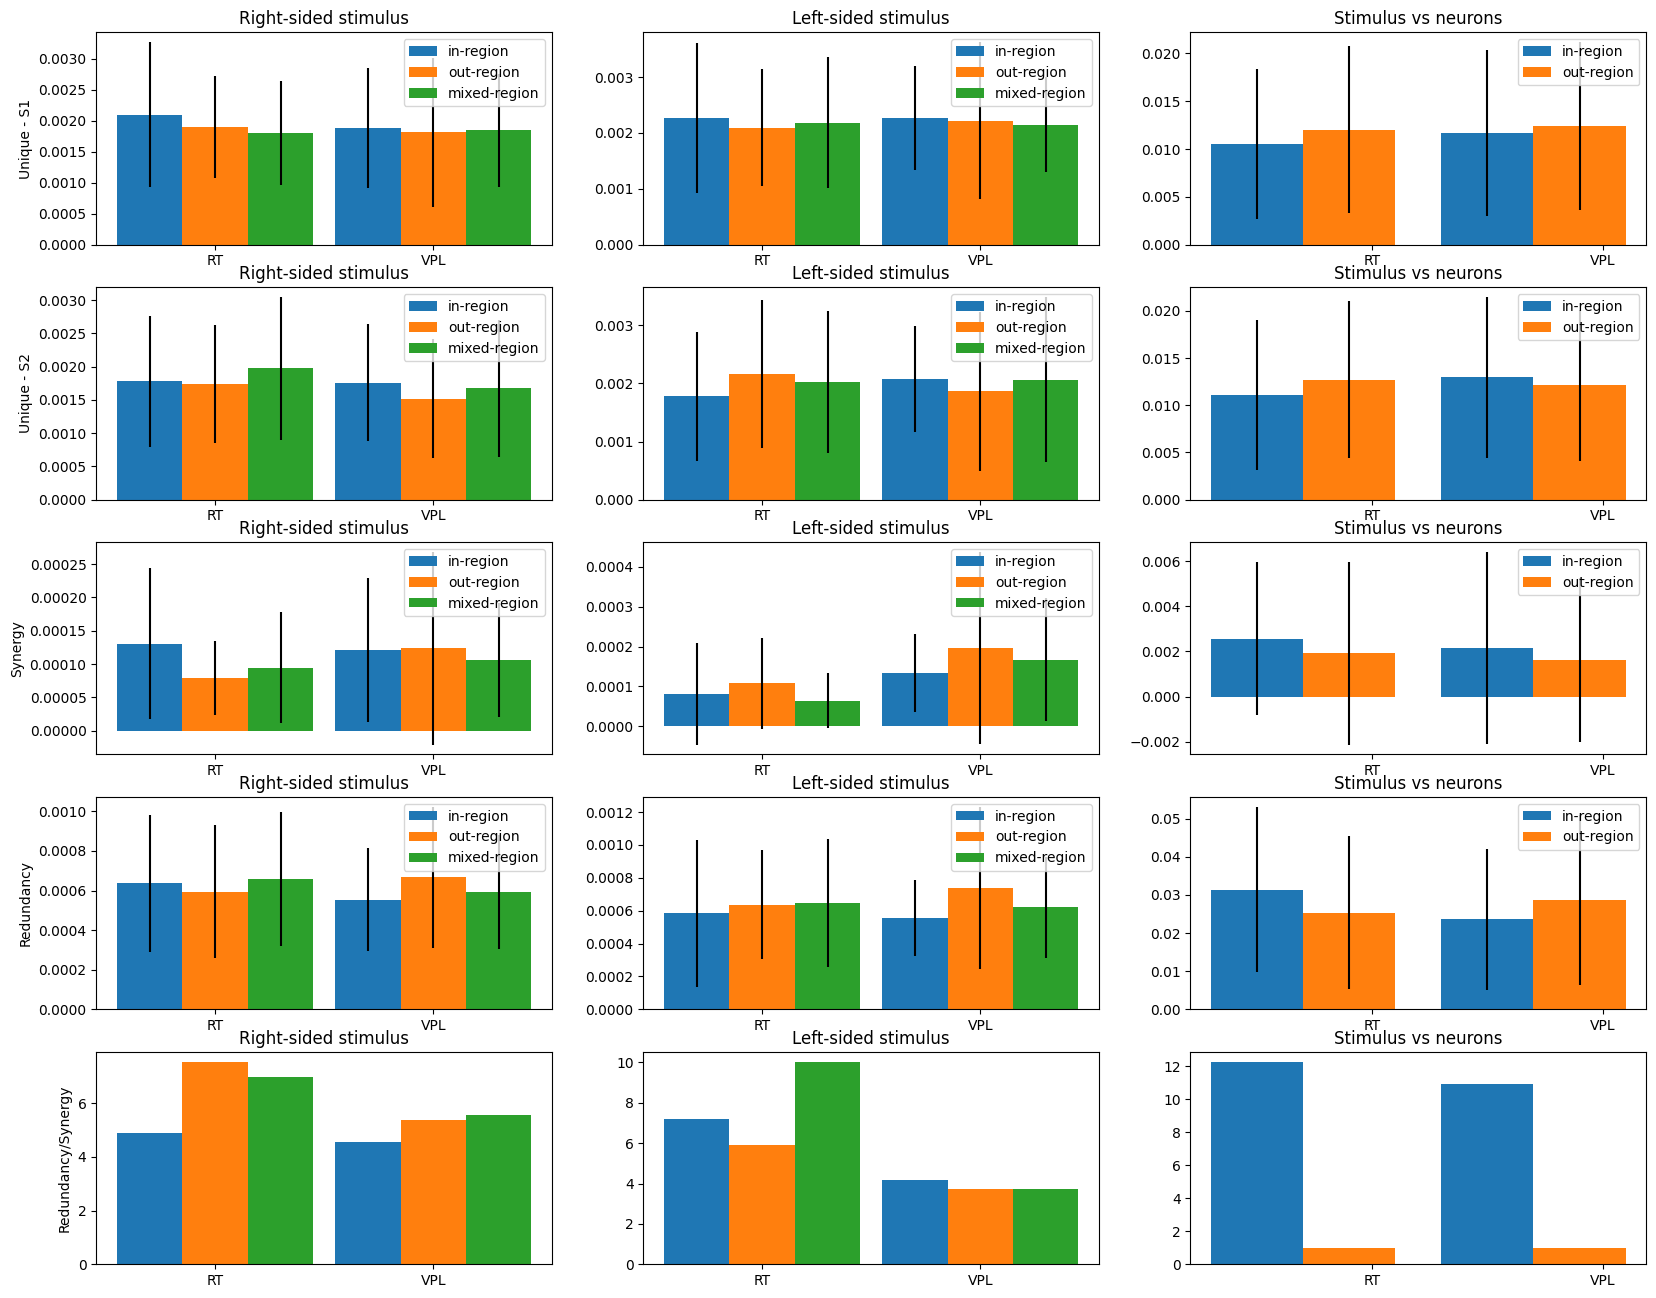

In [44]:
# combine everything; makes more sense

fig, ax = plt.subplots(figsize=(20, 16), nrows=5, ncols=3)

for idx in range(5):

    if idx == 4:
        ax[idx, 0].bar(
            np.arange(regions),
            mean_stim_right_inregion[:, idx-1] / mean_stim_right_inregion[:, idx-2],
            width=0.3,
            label="in-region",
        )
        ax[idx, 0].bar(
            np.arange(regions) + 0.3,
            mean_stim_right_outregion[:, idx-1] / mean_stim_right_outregion[:, idx-2],
            width=0.3,
            label="out-region",
        )
        ax[idx, 0].bar(
            np.arange(regions) + 0.6,
            mean_stim_right_mixedregion[:, idx-1] / mean_stim_right_mixedregion[:, idx-2],
            width=0.3,
            label="mixed-region",
        )

        ax[idx, 1].bar(
            np.arange(regions),
            mean_stim_left_inregion[:, idx-1] / mean_stim_left_inregion[:, idx-2],
            width=0.3,
            label="in-region",
        )
        ax[idx, 1].bar(
            np.arange(regions) + 0.3,
            mean_stim_left_outregion[:, idx-1] / mean_stim_left_outregion[:, idx-2],
            width=0.3,
            label="out-region",
        )
        ax[idx, 1].bar(
            np.arange(regions) + 0.6,
            mean_stim_left_mixedregion[:, idx-1] / mean_stim_left_mixedregion[:, idx-2],
            width=0.3,
            label="mixed-region",
        )

        ax[idx, 2].bar(
            np.arange(regions) - 0.2,
            mean_stim_decoding_inregion[:, idx-1] / mean_stim_decoding_inregion[:, idx-2],
            width=0.4,
            label="in-region",
        )
        ax[idx, 2].bar(
            np.arange(regions) + 0.2,
            mean_stim_decoding_outregion[:, idx-1] / mean_stim_decoding_outregion[:, idx-1],
            width=0.4,
            label="out-region",
        )
        # ax[idx, 0].legend()
        # ax[idx, 1].legend()
        # ax[idx, 2].legend()

        ax[idx, 0].set_xticks(np.arange(regions)+0.3, np.unique(neuron_location_stim))
        ax[idx, 1].set_xticks(np.arange(regions)+0.3, np.unique(neuron_location_stim))
        ax[idx, 2].set_xticks(np.arange(regions)+0.3, np.unique(neuron_location_stim))

        ax[idx, 0].set_title("Right-sided stimulus")
        ax[idx, 1].set_title("Left-sided stimulus")
        ax[idx, 2].set_title("Stimulus vs neurons")

        ax[idx, 0].set_ylabel('Redundancy/Synergy')

        
    else:
        regions = mean_stim_right_inregion.shape[0]

        ax[idx, 0].bar(
            np.arange(regions),
            mean_stim_right_inregion[:, idx],
            width=0.3,
            yerr=inregion_std_stim_right[:, idx],
            label="in-region",
        )
        ax[idx, 0].bar(
            np.arange(regions) + 0.3,
            mean_stim_right_outregion[:, idx],
            width=0.3,
            yerr=outregion_std_stim_right[:, idx],
            label="out-region",
        )
        ax[idx, 0].bar(
            np.arange(regions) + 0.6,
            mean_stim_right_mixedregion[:, idx],
            width=0.3,
            yerr=mixedregion_std_stim_right[:, idx],
            label="mixed-region",
        )

        ax[idx, 1].bar(
            np.arange(regions),
            mean_stim_left_inregion[:, idx],
            width=0.3,
            yerr=inregion_std_stim_left[:, idx],
            label="in-region",
        )
        ax[idx, 1].bar(
            np.arange(regions) + 0.3,
            mean_stim_left_outregion[:, idx],
            width=0.3,
            yerr=outregion_std_stim_left[:, idx],
            label="out-region",
        )
        ax[idx, 1].bar(
            np.arange(regions) + 0.6,
            mean_stim_left_mixedregion[:, idx],
            width=0.3,
            yerr=mixedregion_std_stim_left[:, idx],
            label="mixed-region",
        )

        ax[idx, 2].bar(
            np.arange(regions) - 0.2,
            mean_stim_decoding_inregion[:, idx],
            width=0.4,
            yerr=inregion_std_stim_decoding[:, idx],
            label="in-region",
        )
        ax[idx, 2].bar(
            np.arange(regions) + 0.2,
            mean_stim_decoding_outregion[:, idx],
            width=0.4,
            yerr=outregion_std_stim_decoding[:, idx],
            label="out-region",
        )

        ax[idx, 0].legend()
        ax[idx, 1].legend()
        ax[idx, 2].legend()

        ax[idx, 0].set_xticks(np.arange(regions)+0.3, np.unique(neuron_location_stim))
        ax[idx, 1].set_xticks(np.arange(regions)+0.3, np.unique(neuron_location_stim))
        ax[idx, 2].set_xticks(np.arange(regions)+0.3, np.unique(neuron_location_stim))

        ax[idx, 0].set_title("Right-sided stimulus")
        ax[idx, 1].set_title("Left-sided stimulus")
        ax[idx, 2].set_title("Stimulus vs neurons")
        if idx==0:
            ax[idx, 0].set_ylabel('Unique - S1')
        elif idx==1:
            ax[idx, 0].set_ylabel('Unique - S2')
        elif idx==2:
            ax[idx, 0].set_ylabel('Synergy')
        elif idx==3:
            ax[idx, 0].set_ylabel('Redundancy')
        

In [ ]:
## BROJA estimate

